In [1]:
import numpy as np
import time
import gymnasium as gym
import random
import torch
from collections import namedtuple, Counter
import matplotlib.pyplot as plt
import os
import sys
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))

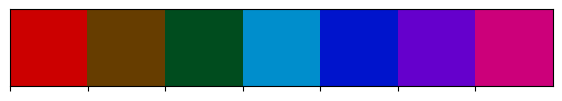

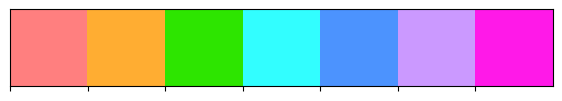

In [2]:
from src.policy_analysis import plot_visit_table_counts, plot_env_actions
from src.wrappers.env_wrappers import ChannelsObs, StochasticAction, TimeStepReward
from src.wrappers.monitor_wrappers import BinaryMonitor

In [3]:
def plot_policy(model, save_fig):
    actions_ind = []
    penalty_vec = np.load("../cc_general_models/9_9/Penalty/reward_model/env_0.0/obs_vector.npy")
    actions = np.zeros((int(grid_size[0] * grid_size[1]), 2))
    q_values = np.zeros((int(grid_size[0] * grid_size[1]), 8))
    count = 0
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            vec = torch.zeros((1, 9, 9), device="mps:0")
            vec[0, i, j] = 1
            obs = torch.cat((vec, torch.from_numpy(penalty_vec).to("mps:0")))
            with torch.no_grad():
                q_values[count] = q_model(obs.unsqueeze(0)).detach().cpu().numpy().squeeze()
                actions_ind.append(select_action(q_values[count]))
            actions[count, 0], actions[count, 1] = actions_ind[-1] % 4, actions_ind[-1] // 4
            count += 1
    fig = plot_env_actions("Penalty", states=np.arange(grid_size[0] * grid_size[1]), actions=actions, grid_size=(9,9))
    if save_fig:
        fig.savefig(main_dir + "/final_policy_plot_{}".format(seed), dpi=300)

def eval_policy(q_model, n_episodes, gamma = 0.99):
    ep_reward, ep_timestep = [], []
    for i in range(n_episodes):
        s, _ = env.reset()
        total_r, timestep = 0, 0
        done = False
        while not done and timestep < 5000:
            with torch.no_grad():
                q_values = q_model(torch.tensor(s["mdp"], dtype=torch.float32, device="mps:0").unsqueeze(0))
            action = q_values.max(1).indices.view(1, 1).item()
            s, r, done, _, info = env.step({"mdp": action % 4, "monitor": action // 4})
            reward = info["mdp_reward"] + r["monitor"]
            total_r += reward * (gamma ** timestep)
            timestep += 1
        ep_reward.append(total_r)
        ep_timestep.append(timestep)
    return np.array(ep_reward), np.array(ep_timestep)

def select_action(q_values) -> int:
    indx = np.argwhere(q_values == np.max(q_values))
    return random.choice(indx)[0]

In [4]:
seed = 9
grid_size = (9, 9)
n_checkpoints = 5
main_dir = "../cc_general_models/9_9/Penalty/reward_model/env_0.0/eps_decay/goal_10_adam_itr_5000/q_lr_0.0005/reward_lr_0.001/"

env = gym.make("gym_monitor/TreasureHunt-Penalty-v1", render_modes="human", seed=seed)
env = ChannelsObs(env, grid_size=(9,9), n_objects=3)
env = TimeStepReward(env, timestep_penalty=0.0, goal_reward=1, fire_reward=-10)
env = BinaryMonitor(env, full_monitor=False, monitor_cost=0.2, init_monitor_state=0.0, monitor_reset_prob=0.0)

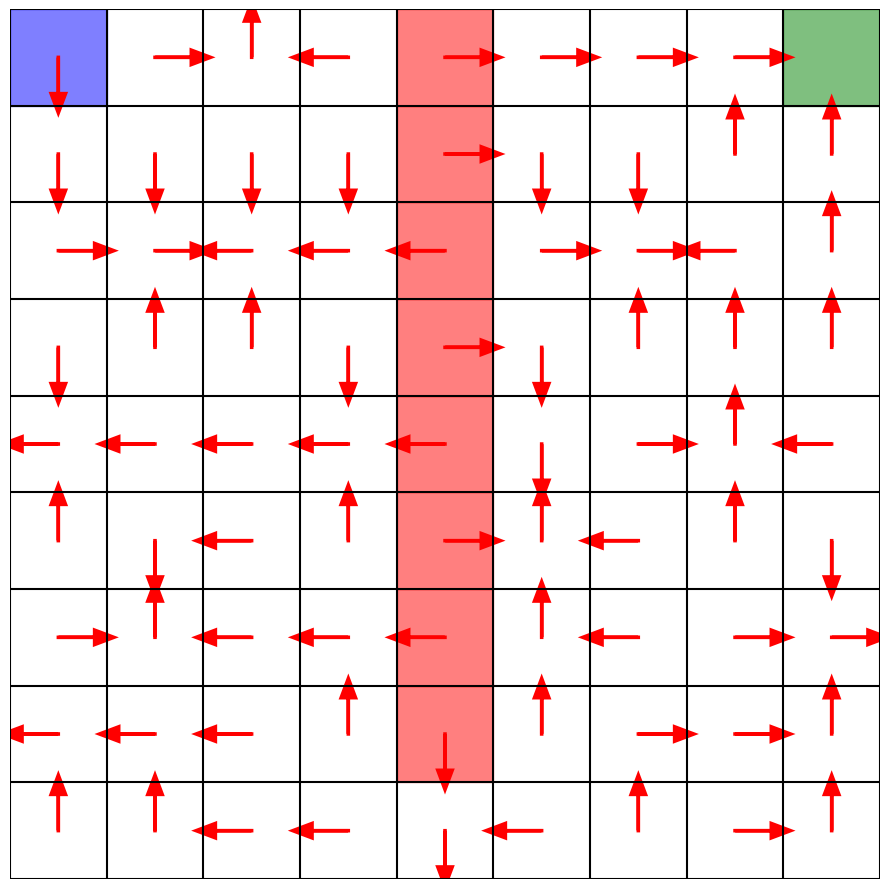

In [5]:
checkpoint = 4
# eval = np.load(main_dir + "/evaluation_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
# n_steps = np.load(main_dir + "/number_of_timesteps_{}.npy".format(seed))
log_flie = main_dir + "checkpoints_{}".format(checkpoint)

reward_loss = np.load(log_flie + "/reward_model_loss_{}.npy".format(seed))
q_loss = np.load(log_flie + "/q_network_loss_{}.npy".format(seed))
reward_model = torch.load(log_flie + "/reward_model_{}".format(seed), map_location=torch.device("mps:0"))
q_model = torch.load(log_flie + "/q_network_{}".format(seed), map_location=torch.device("mps:0"))
# q_model_final = torch.load(main_dir + "/q_network_{}".format(seed), map_location=torch.device("mps:0"))

plot_policy(q_model, save_fig=False)

In [53]:
eval_rewards, eval_timestep = [], []
for checkpoint in range(n_checkpoints):
    q_model = torch.load(main_dir + "/checkpoints_{}/q_network_{}".format(checkpoint, seed), map_location=torch.device("mps:0"))
    ep_r, ep_t = eval_policy(q_model, 1)
    eval_rewards.append(ep_r)
    eval_timestep.append(ep_t)
# np.squeeze(eval_rewards), np.squeeze(eval_timestep)

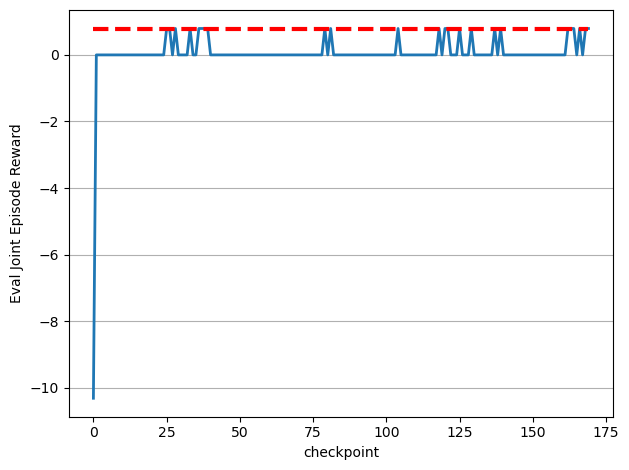

In [55]:
plt.plot(np.squeeze(eval_rewards), lw=2)
# plt.scatter(np.arange(len(eval_rewards)), np.squeeze(eval_rewards), marker="o", s=40)
plt.hlines(0.79, 0, n_checkpoints - 1, color="r", lw=3, linestyle="--")
plt.xlabel("checkpoint")
plt.ylabel("Eval Joint Episode Reward")
plt.grid(axis="y")
# plt.ylim(-0.01, 0.8)
plt.tight_layout()
plt.savefig(main_dir + "/checkpoint_eval_joint_reward_{}.png".format(seed), dpi=300)

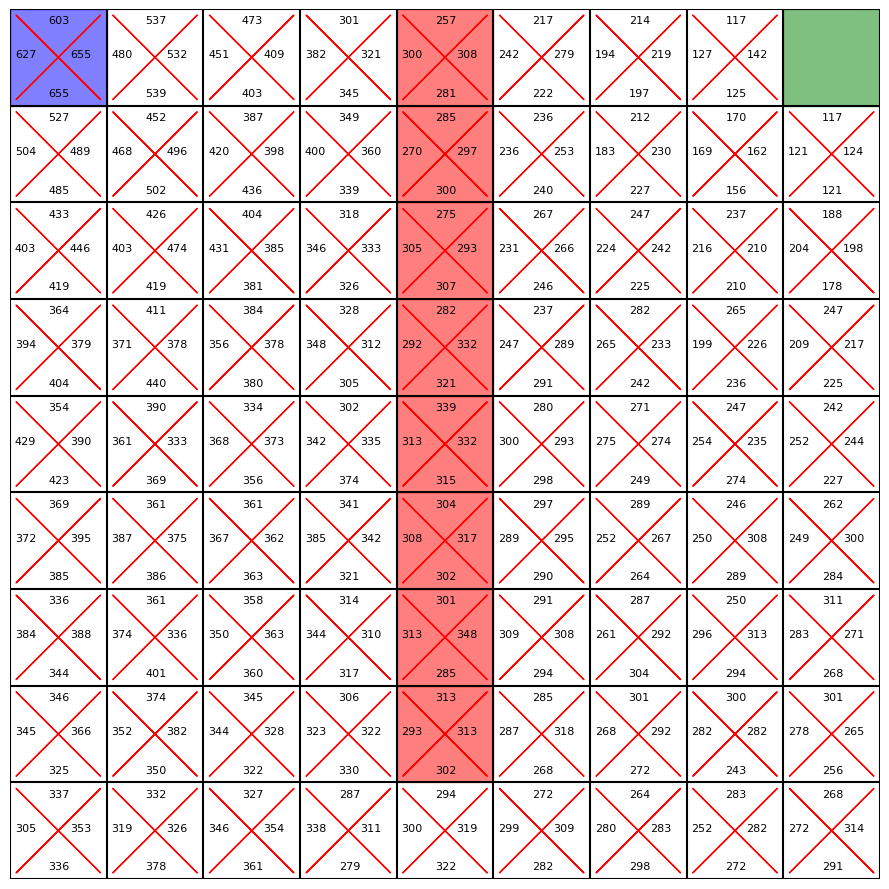

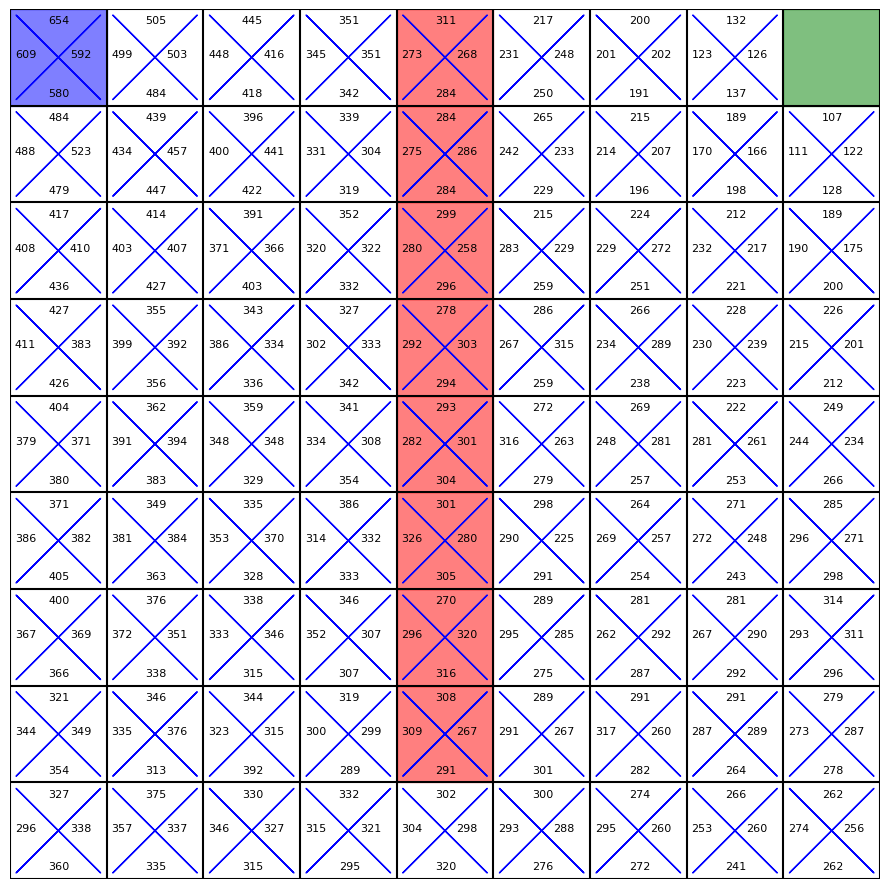

In [15]:
plot_visit_table_counts(log_flie, seed=seed, save_fig=False)

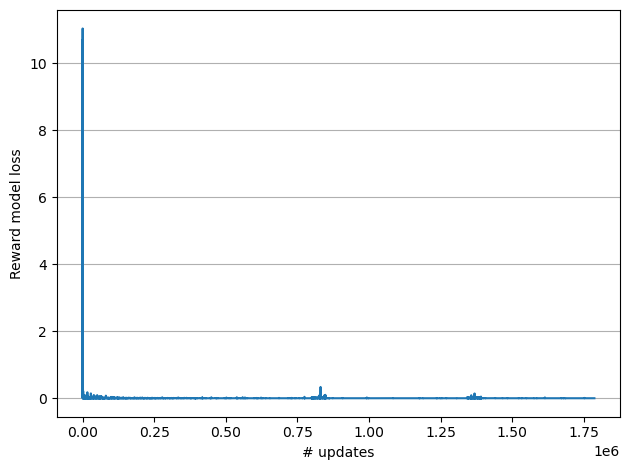

In [22]:
plt.plot(reward_loss)
plt.xlabel("# updates")
plt.ylabel("Reward model loss")
plt.grid(axis="y")
plt.tight_layout()

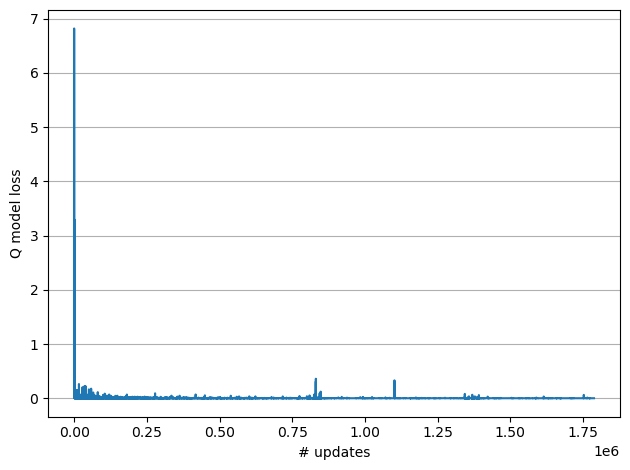

In [23]:
plt.plot(q_loss)
plt.xlabel("# updates")
plt.ylabel("Q model loss")
plt.grid(axis="y")
plt.tight_layout()

In [9]:
Transition = namedtuple("Transition", ("obs", "action", "next_obs", "reward"))

def process_batch(batch, device: str):
    batch = Transition(*zip(*batch))
    real_reward_mask = [not np.isnan(p) for p in [r["mdp"] for r in batch.reward]]
    if len(real_reward_mask) == 0:
        raise ValueError("All nan")
    real_reward_idx = [i for i, x in enumerate(real_reward_mask) if x]
    non_final_mask = torch.tensor(tuple(map(lambda s: s["mdp"] is not None, batch.next_obs)), dtype=torch.bool)
    if device in ["cpu", None]:
        non_final_next_states = torch.tensor(
            np.array([s["mdp"] for s in batch.next_obs if s["mdp"] is not None]), dtype=torch.float,
        )
        mdp_obs = torch.tensor(np.array([state["mdp"] for state in batch.obs]), dtype=torch.float)
        mon_obs = torch.tensor(np.array([state["monitor"] for state in batch.obs]), dtype=torch.float)
        mdp_reward = torch.tensor(np.array([reward["mdp"] for reward in batch.reward]), dtype=torch.float)
        mon_reward = torch.tensor(np.array([reward["monitor"] for reward in batch.reward]), dtype=torch.float)
        mdp_action = torch.tensor(np.array([a["mdp"] for a in batch.action]))
        mon_action = torch.tensor(np.array([a["monitor"] for a in batch.action]))
    else:
        non_final_mask = torch.tensor(tuple(map(lambda s: s["mdp"] is not None, batch.next_obs)), dtype=torch.bool)
        non_final_next_states = torch.tensor(
            np.array([s["mdp"] for s in batch.next_obs if s["mdp"] is not None]), device=device, dtype=torch.float,
        )
        
        mdp_obs = torch.tensor(np.array([state["mdp"] for state in batch.obs]), device=device, dtype=torch.float)
        mon_obs = torch.tensor(np.array([state["monitor"] for state in batch.obs]), device=device, dtype=torch.float)
    
    
        mdp_reward = torch.tensor(np.array([reward["mdp"] for reward in batch.reward]), device=device, dtype=torch.float)
        mon_reward = torch.tensor(np.array([reward["monitor"] for reward in batch.reward]), device=device, dtype=torch.float)
    
        mdp_action = torch.tensor(np.array([a["mdp"] for a in batch.action]), device=device)
        mon_action = torch.tensor(np.array([a["monitor"] for a in batch.action]), device=device)

    process_batch = {
        "real_reward_idx": real_reward_idx,
        "mdp_obs": mdp_obs,
        "mon_obs": mon_obs.unsqueeze(1),
        "non_final_mask": non_final_mask,
        "non_final_next_states": non_final_next_states,
        "mdp_reward": mdp_reward.unsqueeze(1),
        "mon_reward": mon_reward.unsqueeze(1),
        "mdp_action": mdp_action.unsqueeze(1),
        "mon_action": mon_action.unsqueeze(1),
    }
    return process_batch

In [10]:
mon_buffer = np.load("../models/9_9/Penalty/reward_model/env_0.0/eps_1.0/q_lr_1.0/reward_lr_1.0/replay_buffer.npy", allow_pickle=True)[()]

In [24]:
samples = random.sample(list(mon_buffer), 128)
batch = process_batch(samples, "mps:0")
real_reward_idx = batch["real_reward_idx"]
np.where(np.array(batch["mdp_reward"][real_reward_idx].to("cpu")).squeeze() > 0)

(array([12]),)

In [26]:
p = 12
print(batch["mdp_obs"][real_reward_idx][p][0])
print("reward", reward_model(batch["mdp_obs"][real_reward_idx][p].unsqueeze(0)))
print("q values", q_model(batch["mdp_obs"][real_reward_idx][p].unsqueeze(0)))

tensor([[0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')
reward tensor([[ 0.2103,  0.4354, 10.5760,  0.1085]], device='mps:0',
       grad_fn=<LinearBackward0>)
q values tensor([[-0.0557, -0.0575, -0.0655, -0.0841, -0.0643, -0.0630, -0.1025, -0.1096]],
       device='mps:0', grad_fn=<LinearBackward0>)


In [52]:
q_values[5]

NameError: name 'q_values' is not defined

In [16]:
a = batch["mdp_obs"][real_reward_idx][p][1:].to("cpu")
np.array(a).shape

(2, 9, 9)